In [7]:
!pip install ultralytics
#!pip install matplotlib
#pip install pandas


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 4.9 MB/s eta 0:00:0000:0100:01


In [1]:
from ultralytics import YOLO
# Load YOLO11 segmentation model
model = YOLO("yolov8m-seg.pt")  # other options: yolo11m-seg.pt, yolo11l-seg.pt, yolo11x-seg.pt

In [6]:
model.info()

YOLOv8s-seg-custom summary: 216 layers, 10,646,448 parameters, 10,646,432 gradients, 41.6 GFLOPs


(216, 10646448, 10646432, 41.582336)

In [1]:
from ultralytics import YOLO
from ultralytics.nn.modules import CBAM
import torch.nn as nn


model = YOLO("yolov8s-seg-custom.yaml")
model.info()


#model.train(data="./merged_dataset/data.yaml", epochs=100, imgsz=640, batch=24)

YOLOv8s-seg-custom summary: 200 layers, 12,438,384 parameters, 12,438,368 gradients, 64.0 GFLOPs


(200, 12438384, 12438368, 63.989401599999994)

In [5]:
from ultralytics import YOLO

# Load the model
model = YOLO('yolov8s-seg.pt')
pytorch_model = model.model

# YOLOv8-seg has a specific segmentation head
print("YOLOv8s-seg Model Components:")
print("=" * 50)

# Print the entire model structure with focus on segmentation head
print("\nModel Structure:")
print(pytorch_model)

# Specifically look at the model's head (where segmentation happens)
if hasattr(pytorch_model, 'model'):
    # For YOLOv8, the last part is typically the head
    print("\nSegmentation Head Layers:")
    for i, layer in enumerate(pytorch_model.model[-1:]):
        print(f"Head Layer {i}: {layer}")
        
        # If it's the Detect or Segment module, show its structure
        if hasattr(layer, 'cv2') and hasattr(layer, 'cv3'):
            print(f"  - Detection convolutions: {layer.cv2}")
            print(f"  - Segmentation convolutions: {layer.cv3}")

YOLOv8s-seg Model Components:

Model Structure:
SegmentationModel(
  (model): Sequential(
    (0): Conv(
      (conv): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
      (act): SiLU(inplace=True)
    )
    (1): Conv(
      (conv): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
      (act): SiLU(inplace=True)
    )
    (2): C2f(
      (cv1): Conv(
        (conv): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (cv2): Conv(
        (conv): Conv2d(96, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, track_running_stats=T

In [2]:
model.load('./runs/segment/train6/weights/best.pt')

Transferred 270/465 items from pretrained weights


YOLO(
  (model): SegmentationModel(
    (model): Sequential(
      (0): Conv(
        (conv): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (1): Conv(
        (conv): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (2): C2f(
        (cv1): Conv(
          (conv): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
          (act): SiLU(inplace=True)
        )
        (cv2): Conv(
          (conv): Conv2d(96, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, track_runnin

In [5]:
import torch
from ultralytics import YOLO
import numpy as np

def debug_model():
    # Create model
    model = YOLO("yolov8s-seg-custom.yaml")
    
    # Test 1: Check input/output shapes
    print("Test 1: Forward pass with dummy data")
    dummy = torch.randn(2, 3, 640, 640)
    
    try:
        with torch.no_grad():
            outputs = model.model(dummy)
            print(f"Success! Output types: {type(outputs)}")
            
            if isinstance(outputs, tuple):
                boxes, masks = outputs
                print(f"Boxes shape: {boxes.shape}")
                print(f"Masks shape: {masks.shape}")
    except Exception as e:
        print(f"Forward pass error: {e}")
    
    # Test 2: Check if it's a training-time issue
    print("\nTest 2: Simulating training loss calculation")
    
    # Create fake predictions and targets
    pred_masks = torch.randn(2, 32, 160, 160)  # Example mask prediction
    target_masks = torch.randn(2, 1, 640, 640)  # Example ground truth
    
    # Try to calculate IoU (this is where your error occurs)
    print(f"Pred masks shape: {pred_masks.shape}")
    print(f"Target masks shape: {target_masks.shape}")
    
    # Test 3: Check BatchNorm in frozen backbone
    print("\nTest 3: Checking BatchNorm layers")
    for name, module in model.model.named_modules():
        if isinstance(module, torch.nn.BatchNorm2d):
            print(f"BatchNorm: {name}")
            print(f"  Training: {module.training}")
            print(f"  Requires grad: {module.weight.requires_grad}")

debug_model()

Test 1: Forward pass with dummy data
Success! Output types: <class 'dict'>

Test 2: Simulating training loss calculation
Pred masks shape: torch.Size([2, 32, 160, 160])
Target masks shape: torch.Size([2, 1, 640, 640])

Test 3: Checking BatchNorm layers
BatchNorm: model.0.bn
  Training: True
  Requires grad: True
BatchNorm: model.1.bn
  Training: True
  Requires grad: True
BatchNorm: model.2.cv1.bn
  Training: True
  Requires grad: True
BatchNorm: model.2.cv2.bn
  Training: True
  Requires grad: True
BatchNorm: model.2.m.0.cv1.bn
  Training: True
  Requires grad: True
BatchNorm: model.2.m.0.cv2.bn
  Training: True
  Requires grad: True
BatchNorm: model.3.bn
  Training: True
  Requires grad: True
BatchNorm: model.4.cv1.bn
  Training: True
  Requires grad: True
BatchNorm: model.4.cv2.bn
  Training: True
  Requires grad: True
BatchNorm: model.4.m.0.cv1.bn
  Training: True
  Requires grad: True
BatchNorm: model.4.m.0.cv2.bn
  Training: True
  Requires grad: True
BatchNorm: model.4.m.1.cv1.b

In [ ]:
import yaml

# Load the two YAML files
with open("tacodatasetv2/data.yaml") as f:
    data0 = yaml.safe_load(f)
with open("trashdatasetbig/data.yaml") as f:
    data1 = yaml.safe_load(f)
with open("tacodatasetv1/data.yaml") as f:
    data2 = yaml.safe_load(f)
with open("trashcanholedataset/data.yaml") as f:
    data3 = yaml.safe_load(f)

# Get the class names
classes0 = set(data0["names"])
classes1 = set(data1["names"])
classes2 = set(data2["names"])
classes3 = set(data3["names"])


# Union of the two sets
merged_classes = classes0 | classes1 | classes2 | classes3  # or classes1.union(classes2)

# Print the merged set
print(merged_classes)
#for cls in classes0 ^ classes2:
#    print(cls)

# papper straw plastic straw straw

In [ ]:
import os
import shutil

Paper = ["Paper", "Normal paper", "Paper cup", "Paper straw", "Paper bag", "Carded blister pack", "Magazine paper", "Wrapping paper", "Tissues"]
Carton = ["Corrugated carton", "Meal carton", "Pizza box", "Carton", "Other carton", "Egg carton", "Drink carton"]
Plastic =  ["Blister pack","Plastic container", "Plastic lid", "Plastic straw", "Plastic bottle cap", "Other plastic cup", "Other plastic bottle", "Plasticbag-wrapper", "Single-use carrier bag", "Other plastic wrapper", "Clear plastic bottle", "Polypropylene bag", "Tupperware", "Squeezable tube", "Disposable plastic cup", "Plastic film", "Plastic utensils", "Foam food container", "Foam cup", "Styrofoam piece", "Disposable food container", "Plastic glooves", "Other plastic", "Bottle cap", "Other plastic container", "Six pack rings"]
Glass = ["Glass bottle", "Glass jar", "Glass cup", "Broken glass"]
Metal = ["Food Can", "Drink can", "Aerosol", "Scrap metal", "Metal lid", "Metal bottle cap", "Pop tab", "Aluminium foil", "Aluminium blister pack", "Can"]
Organic =  ["Food waste", "Spread tub"]
Cigarette = ["Cigarette"]
Trashcan = ["trashcan-holes"]
Small_Uncategorized_items = ["Straw", "Rope - strings", "Bottle","Cup", "Lid", "Crisp packet", "Battery", "Toilet tube"]
Unlabeled_litter = ["Unlabeled litter","Shoe"]
Garbage_bag = ["Garbage bag"]

categories = [
    Paper, Carton, Plastic, Glass, Metal,
    Organic, Cigarette, Trashcan,
    Small_Uncategorized_items, Unlabeled_litter, Garbage_bag
]

categories_names = ["Paper", "Carton", "Plastic", "Glass", "Metal",
    "Organic", "Cigarette", "Trashcan",
    "Small_Uncategorized_items", "Unlabeled_litter", "Garbage_bag"]

dataset_paths = [
    "./tacodatasetv2",
    "./trashdatasetbig",
    "./tacodatasetv1",
    "./trashcanholedataset",
]

out_root = "./merged_dataset"

# Output folders (YOLOv11 style)
splits = ["train", "valid"]
for split in splits:
    os.makedirs(os.path.join(out_root, split, "images"), exist_ok=True)
    os.makedirs(os.path.join(out_root, split, "labels"), exist_ok=True)

class_map = {}
for new_id, group in enumerate(categories):
    for name in group:
        class_map[name] = new_id

print(class_map)

# ===========================
# MERGE + REMAP
# ===========================
img_counter = {"train": 0, "valid": 0}

for dataset in dataset_paths:
    # Load original class names
    with open(os.path.join(dataset, "data.yaml")) as f:
        import yaml
        old_names = yaml.safe_load(f)["names"]
        old_names = list(old_names)

    for split in splits:
        img_src = os.path.join(dataset, split, "images")
        lbl_src = os.path.join(dataset, split, "labels")

        for img in os.listdir(img_src):
            if not img.lower().endswith((".jpg",".png",".jpeg")):
                continue

            new_name = f"{img_counter[split]:07d}.jpg"
            img_counter[split] += 1

            # Copy image
            shutil.copy2(
                os.path.join(img_src, img),
                os.path.join(out_root, split, "images", new_name)
            )

            # Remap label
            src_lbl = os.path.join(lbl_src, img.rsplit(".",1)[0] + ".txt")
            dst_lbl = os.path.join(out_root, split, "labels", new_name.replace(".jpg",".txt"))

            if not os.path.exists(src_lbl):
                continue

            new_lines = []
            with open(src_lbl) as f:
                for line in f:
                    parts = line.split()
                    old_id = int(parts[0])
                    old_name = old_names[old_id]
                    if old_name in class_map:
                        new_id = class_map[old_name]
                        new_lines.append(" ".join([str(new_id)] + parts[1:]))

            with open(dst_lbl, "w") as f:
                f.write("\n".join(new_lines))

# ===========================
# CREATE data.yaml
# ===========================
with open(os.path.join(out_root, "data.yaml"), "w") as f:
    f.write(
        f"""train: train/images
val: valid/images

nc: {len(categories)}
names:
"""
    )
    for i, group in enumerate(categories):
        f.write(f"  {i}: {categories_names[i]}\n")

print("✅ YOLOv11 dataset created:", out_root)

In [ ]:
import os
from collections import Counter
import yaml

# Load class names
with open("./merged_dataset/data.yaml") as f:
    data = yaml.safe_load(f)

names = {int(k): v for k, v in data["names"].items()}

# Paths to label folders
label_dirs = [
    "./merged_dataset/train/labels",
    #"./merged_dataset/valid/labels"
]

counter = Counter()

for lbl_dir in label_dirs:
    for lbl_file in os.listdir(lbl_dir):
        if not lbl_file.endswith(".txt"):
            continue
        path = os.path.join(lbl_dir, lbl_file)
        with open(path) as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) == 0:
                    continue
                cls_id = int(parts[0])
                cls_name = names.get(cls_id, f"unknown_{cls_id}")
                counter[cls_name] += 1

# Print frequencies
for cls_name, count in sorted(counter.items()):
    print(f"{cls_name}: {count}")


In [ ]:
import cv2
import yaml
import numpy as np
import matplotlib.pyplot as plt
from ultralytics.data.dataset import YOLODataset

# Load YAML
with open("./merged_dataset/data.yaml") as f:
    data = yaml.safe_load(f)

dataset = YOLODataset(
    img_path="./merged_dataset/merged_dataset/train/images",
    data=data,
    task="segment"
)

names = dataset.data["names"]
TARGET_CLASS = "trashcan-holes"

# Collect only images containing target class
items = []
for img_path, label in zip(dataset.im_files, dataset.labels):
    if any(names[int(c)] == TARGET_CLASS for c in label.get("cls", [])):
        items.append((img_path, label))

print(f"Found {len(items)} images with {TARGET_CLASS}")

idx = 0
fig, ax = plt.subplots(figsize=(7, 7))

def draw():
    ax.clear()
    img_path, label = items[idx]

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]

    ax.imshow(img)

    for cls_id, segment in zip(label["cls"], label["segments"]):
        if names[int(cls_id)] != TARGET_CLASS:
            continue

        pts = np.array(segment).reshape(-1, 2)
        pts[:, 0] *= w
        pts[:, 1] *= h
        ax.plot(*pts.T, color="red")
        ax.fill(*pts.T, color="red", alpha=0.3)

    ax.set_title(f"{idx+1}/{len(items)} — {img_path.split('/')[-1]}")
    ax.axis("off")
    fig.canvas.draw_idle()

def on_key(event):
    global idx
    if event.key in ["right", "enter", " "]:
        idx = min(idx + 1, len(items) - 1)
    elif event.key == "left":
        idx = max(idx - 1, 0)
    elif event.key in ["escape", "q"]:
        plt.close(fig)
        return
    draw()

fig.canvas.mpl_connect("key_press_event", on_key)
draw()
plt.show()


In [2]:
import torch
print(torch.version.cuda) # CUDA version PyTorch was built with
print(torch.cuda.is_available()) # True if a GPU is detected
print(torch.cuda.device_count()) # Number of GPUs

13.0
False
0


In [ ]:
# Train on COCO-format dataset
model.train(
    data="./merged_dataset/merged_dataset/data.yaml",
    epochs=150,
    imgsz=640,
    #save_period=10,
    batch=24,
    project="./runs_custom",
    #resume=True,
)

New https://pypi.org/project/ultralytics/8.4.31 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.24 🚀 Python-3.12.3 torch-2.10.0+cu128 CPU (Intel Core i9-14900K)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=./merged_dataset/merged_dataset/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s-seg-custom.yaml, momentum=0.937, mosaic=1.0, multi_scale=0

/home/accenture2/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:1007: UserWarning: Can't initialize NVML
  raw_cnt = _raw_device_count_nvml()


Image sizes 640 train, 640 val
Using 0 dataloader workers
Logging results to /home/accenture2/trashdetector/GarbageDetector/runs/segment/runs_custom/train16
Starting training for 150 epochs...

      Epoch    GPU_mem   box_loss   seg_loss   cls_loss   dfl_loss   sem_loss  Instances       Size
      1/150         0G      3.145       6.77      8.705      4.204          0         27        640: 0% ──────────── 3/2906 9.3s/it 38.9s<7:30:5150


KeyboardInterrupt: 

In [ ]:
import os

# Path to your label folder
label_dir = "./trashcan_hole_dataset/test/labels"

# List to store bad files
bad_files = []

for f in os.listdir(label_dir):
    if not f.endswith(".txt"):
        continue
    path = os.path.join(label_dir, f)
    with open(path, "r") as file:
        lines = file.readlines()
        for line in lines:
            parts = line.strip().split()[1:]  # remove class_id
            # Check for 4 numbers (detect bbox) or odd number (malformed polygon)
            if len(parts) == 4 or len(parts) % 2 != 0:
                bad_files.append(path)
                break  # no need to check the rest of the file

# Delete bad files
for f in bad_files:
    os.remove(f)
    print(f"Deleted bad label file: {f}")

print(f"Total deleted: {len(bad_files)}")

In [27]:
import numpy as np
import matplotlib.pyplot as plt

# Create a simple test image (RGB)
img = np.zeros((300, 300, 3), dtype=np.uint8)

# Draw something visible
img[:] = [255, 0, 0]        # Red background
img[50:250, 50:250] = [0, 255, 0]  # Green square inside

# Plot it
plt.imshow(img)
plt.title("Test Image")
plt.axis("off")
plt.show()
plt.imsave("test_output.png", img)

<Figure size 640x480 with 1 Axes>


image 1/1 /home/accenture2/UltralythicsModelTesting/merged_dataset/merged_dataset/valid/images/0000182.jpg: 640x640 1 Small_Uncategorized_items, 115.1ms
Speed: 1.0ms preprocess, 115.1ms inference, 1.0ms postprocess per image at shape (1, 3, 640, 640)
[ultralytics.engine.results.Results object with attributes:

boxes: ultralytics.engine.results.Boxes object
keypoints: None
masks: ultralytics.engine.results.Masks object
names: {0: 'Paper', 1: 'Carton', 2: 'Plastic', 3: 'Glass', 4: 'Metal', 5: 'Organic', 6: 'Cigarette', 7: 'Trashcan', 8: 'Small_Uncategorized_items', 9: 'Unlabeled_litter', 10: 'Garbage_bag'}
obb: None
orig_img: array([[[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
 

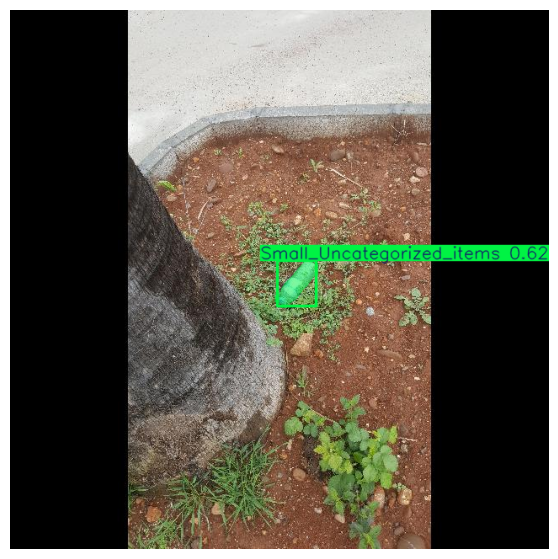

In [14]:
from ultralytics import YOLO
import matplotlib.pyplot as plt

# Load model
model = YOLO("./runs/segment/train6/weights/best.pt")

# Run prediction on ONE image
results = model.predict(
    source="./merged_dataset/merged_dataset/valid/images/0000182.jpg",
    conf=0.2,
    save=False,
    show=False
)

print(results)

# Get plotted image (with predictions drawn)
img_with_preds = results[0].plot()  # returns numpy array (BGR)

# Show with matplotlib
plt.figure(figsize=(7, 7))
plt.imshow(img_with_preds[..., ::-1])  # BGR -> RGB
plt.axis("off")
plt.show()
plt.imsave("test_output2.png", img_with_preds[..., ::-1])

In [49]:
from ultralytics import YOLO
from collections import defaultdict

model = YOLO("./runs/segment/train44/weights/best.pt")

results = model.predict("video2.mp4", conf=0.2,save = True)

class_counts = defaultdict(int)
confidence_sum = defaultdict(float)
total_detections = 0

for r in results:
    if r.boxes is None:
        continue

    for cls, conf in zip(r.boxes.cls, r.boxes.conf):
        cls = int(cls)
        class_counts[cls] += 1
        confidence_sum[cls] += float(conf)
        total_detections += 1

# Convert class IDs → names
names = model.names

print("📊 Summary:")
for cls, count in class_counts.items():
    avg_conf = confidence_sum[cls] / count
    print(f"{names[cls]}: {count} detections, avg conf = {avg_conf:.2f}")

print(f"\nTotal detections: {total_detections}")


WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/259) /home/accenture2/UltralythicsModelTesting/video2.mp4: 384x640 1 Plastic, 1 Metal, 1 Small_Uncategorized_items, 43.2ms
video 1/1 (frame 2/259) /home/accenture2/UltralythicsModelTesting/video2.mp4: 384x640 1 Plastic, 1 Metal, 1 Small_Uncategorized_items, 6.0ms
video 1/1 (frame 3/259) /home/accenture2/UltralythicsModelTesting/video2.mp4: 384x640 1 Plastic, 1 Metal, 1 Small_Uncategorized_items, 6.6ms
video 1/1 (frame 4/259) /home/acce

In [50]:
from ultralytics import YOLO

model = YOLO("./runs/segment/train44/weights/best.pt")
model.export(
    format="onnx",
    imgsz=640,
    opset=21,
    device='cpu',
)

Ultralytics 8.4.24 🚀 Python-3.12.3 torch-2.10.0+cu128 CPU (Intel Core i9-14900K)
YOLOv8s-seg-custom summary (fused): 107 layers, 12,355,868 parameters, 0 gradients, 61.3 GFLOPs

PyTorch: starting from 'runs/segment/train44/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) ((1, 47, 34000), (1, 32, 160, 160)) (24.1 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxslim>=0.1.71', 'onnxruntime-gpu'] not found, attempting AutoUpdate...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/17.5 MB ? eta -:--:--
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/17.5 MB 2.4 MB/s eta 0:00:08
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.1/17.5 MB 1.7 MB/s eta 0:00:11
   ╸━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.3/17.5 MB 2.6 MB/s eta 0:00:07
   ━╺━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.5/17.5 MB 3.5 MB/s eta 0:00:05
   ━╺━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.6/17.5 MB 3.9 MB/s eta 0:00:05
   ━╸━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.7/17.5 MB 3.7 MB

/home/accenture2/.venv/lib/python3.12/site-packages/torch/onnx/_internal/torchscript_exporter/utils.py:552: OnnxExporterWarning: Exporting to ONNX opset version 21 is not supported. by 'torch.onnx.export()'. The highest opset version supported is 20. To use a newer opset version, consider 'torch.onnx.export(..., dynamo=True)'. 
  _export(


ONNX: slimming with onnxslim 0.1.90...
ONNX: export success ✅ 72.6s, saved as 'runs/segment/train44/weights/best.onnx' (47.9 MB)

Export complete (73.2s)
Results saved to /home/accenture2/UltralythicsModelTesting/runs/segment/train44/weights
Predict:         yolo predict task=segment model=runs/segment/train44/weights/best.onnx imgsz=640 
Validate:        yolo val task=segment model=runs/segment/train44/weights/best.onnx imgsz=640 data=./merged_dataset/merged_dataset/data.yaml  
Visualize:       https://netron.app


'runs/segment/train44/weights/best.onnx'

In [1]:
import onnx

# Load your ONNX model
onnx_model = onnx.load("./runs/segment/train6/weights/best.onnx")

# Print all outputs
for output in onnx_model.graph.output:
    print(f"Output name: {output.name}, type: {output.type}")

Output name: output0, type: tensor_type {
  elem_type: 1
  shape {
    dim {
      dim_value: 1
    }
    dim {
      dim_value: 47
    }
    dim {
      dim_value: 8400
    }
  }
}

Output name: output1, type: tensor_type {
  elem_type: 1
  shape {
    dim {
      dim_value: 1
    }
    dim {
      dim_value: 32
    }
    dim {
      dim_value: 160
    }
    dim {
      dim_value: 160
    }
  }
}



In [57]:
import pandas as pd
import matplotlib.pyplot as plt

# Paths to your CSV files
csv_files = [
    "runs/segment/train6/results.csv",
    "runs/segment/train44/results.csv",
    "runs/segment/train40/results.csv"
]

# Create the plot
plt.figure(figsize=(10, 5))

# Loop through CSV files and plot the same metric from each
df = pd.read_csv(csv_files[0])
plt.plot(df['epoch'], df['metrics/mAP50(B)'], marker='o', label=f'mAP50 unmodified model')
df = pd.read_csv(csv_files[1])
plt.plot(df['epoch'], df['metrics/mAP50(B)'], marker='o', label=f'mAP50 our model')
df = pd.read_csv(csv_files[2])
plt.plot(df['epoch'], df['metrics/mAP50(B)'], marker='o', label=f'mAP50 Yolov8m-seg')

plt.xlabel('Epoch')
plt.ylabel('mAP50 (B)')
plt.title('YOLO mAP50 (B) Comparison Across Training Runs')
plt.grid(True)
plt.legend()

# Save the combined plot
plt.savefig("mAP50_B_comparison.png", dpi=300)
plt.close()

In [5]:
import cv2
import numpy as np
from ultralytics import YOLO

class YOLOv8SegAnnotator:
    def __init__(self, model_path='./Data/yolov8s-seg.pt'):
        """Load a YOLOv8 segmentation model"""
        self.model = YOLO(model_path)
        self.latestResults = None
        self.latestImage = None

    def update(self, image_path):
        """Run inference on an image from file path"""
        image = cv2.imread(image_path)
        if image is None:
            raise ValueError(f"Image not found: {image_path}")
        self.latestImage = image.copy()
        # Run prediction and take the first result
        self.latestResults = self.model.predict(image, verbose=False)[0]

    def GetDataRaw(self):
        """Return raw predictions as a list of dicts with bbox, score, label, mask"""
        if self.latestResults is None:
            return []

        predictions = []
        boxes = self.latestResults.boxes.xyxy.cpu().numpy()
        scores = self.latestResults.boxes.conf.cpu().numpy()
        labels = self.latestResults.boxes.cls.cpu().numpy()
        masks = self.latestResults.masks.data.cpu().numpy() if hasattr(self.latestResults, "masks") else None

        for i in range(len(boxes)):
            pred = {
                "bbox": boxes[i],
                "score": float(scores[i]),
                "label": int(labels[i]),
                "mask": {"data": masks[i]} if masks is not None else None
            }
            predictions.append(pred)
        return predictions

    def draw_object_annotations(self, draw_mask_alpha=0.4):
        """Return annotated image with bounding boxes, masks, and PCA orientation lines (shorter lines)"""
        if self.latestResults is None or self.latestImage is None:
            return None
    
        image = self.latestImage.copy()
    
        for det in self.GetDataRaw():
            bbox = det['bbox']
            label = det.get('label', 'Unknown')
            score = det.get('score', 0.0)
            mask_data = det.get('mask', {}).get('data', None)
    
            x_min, y_min, x_max, y_max = [int(v) for v in bbox]
    
            # --- Draw bounding box + label ---
            cv2.rectangle(image, (x_min, y_min), (x_max, y_max), (0, 255, 0), 2)
            cv2.putText(image, f"{label}: {score:.2f}", (x_min, max(y_min - 5, 0)),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)
    
            # --- Overlay full-image mask ---
            if mask_data is not None:
                mask = (mask_data > 0).astype(np.uint8)
                mask_color = np.zeros_like(image, dtype=np.uint8)
                mask_color[:, :, 2] = mask * 255  # Red mask
    
                mask_bool = mask.astype(bool)
                image[mask_bool] = (image[mask_bool] * (1 - draw_mask_alpha) +
                                     mask_color[mask_bool] * draw_mask_alpha).astype(np.uint8)
    
                # --- PCA orientation line (shorter) ---
                ys, xs = np.where(mask > 0)
                if len(xs) > 0:
                    coords = np.column_stack((xs, ys)).astype(np.float32)
                    mean, eigenvectors = cv2.PCACompute(coords, mean=None)[:2]
                    center = tuple(mean[0].astype(int))
                    vec = eigenvectors[0]
    
                    # Shorter line: half of mask diagonal
                    mask_h, mask_w = mask.shape
                    length = 0.5 * np.sqrt(mask_h**2 + mask_w**2)
    
                    pt1 = (int(center[0] - vec[0] * length/10), int(center[1] - vec[1] * length/10))
                    pt2 = (int(center[0] + vec[0] * length/10), int(center[1] + vec[1] * length/10))
                    cv2.line(image, pt1, pt2, (255, 0, 0), 2)
                    cv2.circle(image, center, 3, (0, 255, 255), -1)
    
        return image


# --- Example usage ---
if __name__ == "__main__":
    annotator = YOLOv8SegAnnotator(model_path='runs/segment/train6/weights/best.pt')
    annotator.update('./merged_dataset/merged_dataset/valid/images/0000182.jpg')
    annotated_image = annotator.draw_object_annotations()
    cv2.imwrite('annotated.png', annotated_image)